In [ ]:
# # ============================================================
# #  FACIAL EMOTION RECOGNITION — COMPLETE PIPELINE v2
# #  Dataset : FER2013 (msambare/fer2013) — Image Folders
# #  Models  : Custom CNN | Deep Residual CNN | Mini VGG CNN
# #  Platform: Google Colab (GPU recommended)
# #  NOTE    : All models use native 48x48 grayscale — no upscaling
# # ============================================================

# # ============================================================
# # CELL 1 — Kaggle Setup & Download
# # ============================================================
# import json, os

# KAGGLE_USERNAME = "your_kaggle_username"   # ← Fill this
# KAGGLE_KEY      = "your_kaggle_key"        # ← Fill this

# os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
# with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
#     json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
# os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# os.system("pip install -q kaggle")
# os.system("kaggle datasets download -d msambare/fer2013")
# os.system("unzip -q fer2013.zip -d fer2013_images")
# print("✅ Dataset ready!")

# # ============================================================
# # CELL 2 — Imports
# # ============================================================
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# import warnings
# warnings.filterwarnings('ignore')

# from pathlib import Path
# from PIL import Image
# import collections

# from sklearn.metrics import (classification_report, confusion_matrix,
#                              ConfusionMatrixDisplay, f1_score)
# from sklearn.utils.class_weight import compute_class_weight

# import tensorflow as tf
# from tensorflow.keras.models import Sequential, Model
# from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
#                                      Dropout, BatchNormalization,
#                                      GlobalAveragePooling2D, Input,
#                                      Add, Activation)
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

# print("✅ TensorFlow:", tf.__version__)
# print("✅ GPU:", tf.config.list_physical_devices('GPU'))

# # ============================================================
# # CELL 3 — Constants & Paths
# # ============================================================
# TRAIN_DIR       = Path("fer2013_images/train")
# TEST_DIR        = Path("fer2013_images/test")

# EMOTIONS        = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
# EMOTION_DISPLAY = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
# NUM_CLASSES     = 7
# BATCH_SIZE      = 64
# IMG_SIZE        = (48, 48)
# COLORS          = ["#e74c3c","#8e44ad","#2980b9","#f1c40f","#1abc9c","#e67e22","#95a5a6"]

# # Verify folders
# print("\n📁 Dataset Structure:")
# for split_dir in [TRAIN_DIR, TEST_DIR]:
#     print(f"\n  {split_dir.name}/")
#     for emotion in sorted(os.listdir(split_dir)):
#         imgs = (list((split_dir/emotion).glob("*.png")) +
#                 list((split_dir/emotion).glob("*.jpg")))
#         print(f"    └── {emotion:<12} {len(imgs):>5} images")

# # ============================================================
# # CELL 4 — EDA: Class Distribution
# # ============================================================
# print("\n\n── EDA: Class Distribution ──")

# train_counts = {e: len(list((TRAIN_DIR/e).glob("*"))) for e in EMOTIONS}
# test_counts  = {e: len(list((TEST_DIR /e).glob("*"))) for e in EMOTIONS}

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle("EDA — Class Distribution", fontsize=15, fontweight='bold')

# # Train bar chart
# bars = axes[0].bar(EMOTION_DISPLAY,
#                    [train_counts[e] for e in EMOTIONS],
#                    color=COLORS, edgecolor='black', linewidth=0.7)
# axes[0].set_title("Train Set — Sample Count", fontweight='bold')
# axes[0].set_ylabel("Count")
# axes[0].tick_params(axis='x', rotation=30)
# for bar, e in zip(bars, EMOTIONS):
#     axes[0].text(bar.get_x() + bar.get_width()/2,
#                  bar.get_height() + 40, str(train_counts[e]),
#                  ha='center', fontsize=8, fontweight='bold')
# axes[0].grid(axis='y', alpha=0.3)

# # Test bar chart
# axes[1].bar(EMOTION_DISPLAY,
#             [test_counts[e] for e in EMOTIONS],
#             color=COLORS, edgecolor='black', linewidth=0.7, alpha=0.85)
# axes[1].set_title("Test Set — Sample Count", fontweight='bold')
# axes[1].set_ylabel("Count")
# axes[1].tick_params(axis='x', rotation=30)
# axes[1].grid(axis='y', alpha=0.3)

# # Pie chart
# axes[2].pie([train_counts[e] for e in EMOTIONS],
#             labels=EMOTION_DISPLAY, autopct='%1.1f%%',
#             colors=COLORS, startangle=140,
#             wedgeprops=dict(edgecolor='white'))
# axes[2].set_title("Train Set — Distribution (%)", fontweight='bold')

# plt.tight_layout()
# plt.savefig("eda_class_distribution.png", dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\n  Most common : {max(train_counts, key=train_counts.get)} "
#       f"({max(train_counts.values())} images)")
# print(f"  Least common: {min(train_counts, key=train_counts.get)} "
#       f"({min(train_counts.values())} images)")
# print(f"  Imbalance   : {max(train_counts.values())/min(train_counts.values()):.1f}x")

# # ============================================================
# # CELL 5 — EDA: Sample Images per Emotion
# # ============================================================
# fig, axes = plt.subplots(7, 6, figsize=(14, 18))
# fig.suptitle("EDA — Sample Images per Emotion (Train Set)",
#              fontsize=15, fontweight='bold')

# for i, emotion in enumerate(EMOTIONS):
#     paths = (list((TRAIN_DIR/emotion).glob("*.png")) +
#              list((TRAIN_DIR/emotion).glob("*.jpg")))[:6]
#     for j, path in enumerate(paths):
#         img = np.array(Image.open(path).convert('L'))
#         axes[i][j].imshow(img, cmap='gray')
#         axes[i][j].axis('off')
#         if j == 0:
#             axes[i][j].set_ylabel(EMOTION_DISPLAY[i], fontsize=11,
#                                    fontweight='bold', rotation=0,
#                                    labelpad=55, va='center')
# plt.tight_layout()
# plt.savefig("eda_sample_images.png", dpi=150, bbox_inches='tight')
# plt.show()

# # ============================================================
# # CELL 6 — EDA: Average Face per Emotion
# # ============================================================
# fig, axes = plt.subplots(1, 7, figsize=(18, 3))
# fig.suptitle("EDA — Average Face per Emotion", fontsize=14, fontweight='bold')

# for i, emotion in enumerate(EMOTIONS):
#     paths = (list((TRAIN_DIR/emotion).glob("*.png")) +
#              list((TRAIN_DIR/emotion).glob("*.jpg")))[:200]
#     imgs     = [np.array(Image.open(p).convert('L').resize((48, 48))) for p in paths]
#     avg_face = np.mean(imgs, axis=0)
#     axes[i].imshow(avg_face, cmap='gray')
#     axes[i].set_title(EMOTION_DISPLAY[i], fontsize=10, fontweight='bold')
#     axes[i].axis('off')

# plt.tight_layout()
# plt.savefig("eda_average_faces.png", dpi=150, bbox_inches='tight')
# plt.show()

# # ============================================================
# # CELL 7 — EDA: Pixel Intensity Distribution
# # ============================================================
# fig, axes = plt.subplots(2, 4, figsize=(16, 7))
# fig.suptitle("EDA — Pixel Intensity Distribution per Emotion",
#              fontsize=14, fontweight='bold')
# axes = axes.flatten()

# for i, emotion in enumerate(EMOTIONS):
#     paths = (list((TRAIN_DIR/emotion).glob("*.png")) +
#              list((TRAIN_DIR/emotion).glob("*.jpg")))[:100]
#     pixels = []
#     for p in paths:
#         pixels.extend(np.array(Image.open(p).convert('L')).flatten().tolist())
#     axes[i].hist(pixels, bins=50, color=COLORS[i],
#                  edgecolor='black', linewidth=0.3, alpha=0.85)
#     axes[i].set_title(EMOTION_DISPLAY[i], fontweight='bold')
#     axes[i].set_xlabel("Pixel Value (0–255)")
#     axes[i].set_ylabel("Frequency")
#     axes[i].grid(alpha=0.3)

# axes[7].axis('off')
# plt.tight_layout()
# plt.savefig("eda_pixel_distribution.png", dpi=150, bbox_inches='tight')
# plt.show()

# # ============================================================
# # CELL 8 — EDA: Image Quality Check
# # ============================================================
# print("\n── EDA: Image Quality Check ──")
# sizes   = collections.Counter()
# corrupt = 0

# for emotion in EMOTIONS:
#     for path in list((TRAIN_DIR/emotion).glob("*"))[:50]:
#         try:
#             sizes[Image.open(path).size] += 1
#         except Exception:
#             corrupt += 1

# print(f"  Corrupted images : {corrupt}")
# print(f"  Image sizes found:")
# for size, count in sizes.most_common():
#     print(f"    {size[0]}x{size[1]} px → {count} samples")

# # ============================================================
# # CELL 9 — Data Generators
# # ============================================================
# print("\n\n── Setting up Data Generators ──")

# # Augmented generator for training
# train_gen = ImageDataGenerator(
#     rescale=1./255,
#     rotation_range=15,
#     width_shift_range=0.10,
#     height_shift_range=0.10,
#     horizontal_flip=True,
#     zoom_range=0.10,
#     validation_split=0.15
# ).flow_from_directory(
#     TRAIN_DIR,
#     target_size=IMG_SIZE,
#     color_mode='grayscale',
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     subset='training',
#     shuffle=True,
#     seed=42
# )

# # Clean generator for validation
# val_gen = ImageDataGenerator(
#     rescale=1./255,
#     validation_split=0.15
# ).flow_from_directory(
#     TRAIN_DIR,
#     target_size=IMG_SIZE,
#     color_mode='grayscale',
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     subset='validation',
#     shuffle=False,
#     seed=42
# )

# # Clean generator for test
# test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
#     TEST_DIR,
#     target_size=IMG_SIZE,
#     color_mode='grayscale',
#     batch_size=BATCH_SIZE,
#     class_mode='categorical',
#     shuffle=False
# )

# print("\n✅ Class indices:", train_gen.class_indices)

# # Compute class weights to handle Disgust imbalance
# class_weights_arr = compute_class_weight(
#     class_weight='balanced',
#     classes=np.arange(NUM_CLASSES),
#     y=train_gen.classes
# )
# class_weights = {i: w for i, w in enumerate(class_weights_arr)}
# print(f"\n✅ Class weights: {class_weights}")

# # ============================================================
# # CELL 10 — Shared Helpers
# # ============================================================

# def get_callbacks(model_name):
#     """EarlyStopping + ReduceLR + save best checkpoint."""
#     return [
#         EarlyStopping(monitor='val_accuracy', patience=10,
#                       restore_best_weights=True, verbose=1),
#         ReduceLROnPlateau(monitor='val_loss', factor=0.5,
#                           patience=5, min_lr=1e-6, verbose=1),
#         ModelCheckpoint(f"best_{model_name}.keras",
#                         monitor='val_accuracy',
#                         save_best_only=True, verbose=0)
#     ]

# def plot_history(history, model_name):
#     """Plot accuracy and loss curves."""
#     fig, axes = plt.subplots(1, 2, figsize=(13, 4))
#     fig.suptitle(f"Training History — {model_name}",
#                  fontsize=13, fontweight='bold')

#     axes[0].plot(history.history['accuracy'],
#                  label='Train', color='steelblue', lw=2)
#     axes[0].plot(history.history['val_accuracy'],
#                  label='Val', color='tomato', lw=2)
#     axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
#     axes[0].set_ylabel("Accuracy"); axes[0].legend()
#     axes[0].grid(alpha=0.3)

#     axes[1].plot(history.history['loss'],
#                  label='Train', color='steelblue', lw=2)
#     axes[1].plot(history.history['val_loss'],
#                  label='Val', color='tomato', lw=2)
#     axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
#     axes[1].set_ylabel("Loss"); axes[1].legend()
#     axes[1].grid(alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(f"history_{model_name}.png", dpi=150, bbox_inches='tight')
#     plt.show()

# def evaluate_model(model, model_name, test_gen):
#     """Evaluate model — print metrics, plot confusion matrix."""
#     test_gen.reset()
#     loss, acc = model.evaluate(test_gen, verbose=0)
#     test_gen.reset()
#     y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
#     y_true = test_gen.classes

#     print(f"\n── {model_name} Results ──")
#     print(f"  Test Loss    : {loss:.4f}")
#     print(f"  Test Accuracy: {acc*100:.2f}%")
#     print(f"\n  Classification Report:")
#     print(classification_report(y_true, y_pred,
#                                 target_names=EMOTION_DISPLAY))

#     # Confusion matrix
#     cm  = confusion_matrix(y_true, y_pred)
#     fig, ax = plt.subplots(figsize=(8, 6))
#     ConfusionMatrixDisplay(cm, display_labels=EMOTION_DISPLAY).plot(
#         ax=ax, cmap='Blues', colorbar=False)
#     ax.set_title(f"Confusion Matrix — {model_name}", fontweight='bold')
#     plt.xticks(rotation=30)
#     plt.tight_layout()
#     plt.savefig(f"cm_{model_name}.png", dpi=150, bbox_inches='tight')
#     plt.show()

#     return loss, acc, y_pred, y_true

# results = {}   # {model_name: (loss, acc, y_pred, y_true)}

# # ============================================================
# # CELL 11 — MODEL 1: Custom CNN (load saved checkpoint)
# # ============================================================
# print("\n\n══ MODEL 1: Custom CNN (loading saved checkpoint) ══")

# # If you already trained CNN previously, just load it — no need to retrain!
# import os

# if os.path.exists("best_CNN.keras"):
#     from tensorflow.keras.models import load_model
#     cnn_model = load_model("best_CNN.keras")
#     print("✅ Loaded saved CNN from best_CNN.keras")
# else:
#     print("⚠️  No saved checkpoint found — training from scratch...")

#     cnn_model = Sequential([
#         # Block 1
#         Conv2D(32, (3,3), activation='relu', padding='same',
#                input_shape=(48, 48, 1)),
#         BatchNormalization(),
#         Conv2D(32, (3,3), activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2), Dropout(0.25),

#         # Block 2
#         Conv2D(64, (3,3), activation='relu', padding='same'),
#         BatchNormalization(),
#         Conv2D(64, (3,3), activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2), Dropout(0.25),

#         # Block 3
#         Conv2D(128, (3,3), activation='relu', padding='same'),
#         BatchNormalization(),
#         Conv2D(128, (3,3), activation='relu', padding='same'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2), Dropout(0.25),

#         # Classifier head
#         Flatten(),
#         Dense(256, activation='relu'), BatchNormalization(), Dropout(0.5),
#         Dense(128, activation='relu'), Dropout(0.3),
#         Dense(NUM_CLASSES, activation='softmax')
#     ], name="Custom_CNN")

#     cnn_model.compile(optimizer=Adam(1e-3),
#                       loss='categorical_crossentropy',
#                       metrics=['accuracy'])

#     history_cnn = cnn_model.fit(
#         train_gen, epochs=60, validation_data=val_gen,
#         class_weight=class_weights,
#         callbacks=get_callbacks("CNN"), verbose=1
#     )
#     plot_history(history_cnn, "Custom CNN")

# results["Custom CNN"] = evaluate_model(cnn_model, "Custom CNN", test_gen)

# # ============================================================
# # CELL 12 — MODEL 2: Deep Residual CNN
# # ============================================================
# # What makes this different from Model 1:
# #   - Residual (skip) connections: output = F(x) + x
# #   - Prevents vanishing gradients in deeper networks
# #   - Learns both fine and coarse features simultaneously
# #   - More parameters, more representational power
# # ============================================================
# print("\n\n══ MODEL 2: Deep Residual CNN ══")

# def residual_block(x, filters, downsample=False):
#     """
#     A residual block: two Conv layers with a skip connection.
#     If downsample=True, reduces spatial size by 2 using stride.
#     """
#     stride = 2 if downsample else 1

#     # Main path
#     out = Conv2D(filters, (3,3), strides=stride,
#                  padding='same', activation='relu')(x)
#     out = BatchNormalization()(out)
#     out = Conv2D(filters, (3,3), padding='same')(out)
#     out = BatchNormalization()(out)

#     # Skip connection — match dimensions if needed
#     if downsample or x.shape[-1] != filters:
#         x = Conv2D(filters, (1,1), strides=stride, padding='same')(x)
#         x = BatchNormalization()(x)

#     # Add skip + main, then activate
#     out = Add()([out, x])
#     out = Activation('relu')(out)
#     return out

# def build_residual_cnn():
#     inputs = Input(shape=(48, 48, 1))

#     # Entry block
#     x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
#     x = BatchNormalization()(x)

#     # Residual blocks — gradually increase filters
#     x = residual_block(x, 32)
#     x = residual_block(x, 64,  downsample=True)   # 24x24
#     x = Dropout(0.25)(x)

#     x = residual_block(x, 64)
#     x = residual_block(x, 128, downsample=True)   # 12x12
#     x = Dropout(0.25)(x)

#     x = residual_block(x, 128)
#     x = residual_block(x, 256, downsample=True)   # 6x6
#     x = Dropout(0.25)(x)

#     # Global pooling instead of Flatten — more robust
#     x = GlobalAveragePooling2D()(x)
#     x = Dense(256, activation='relu')(x)
#     x = BatchNormalization()(x)
#     x = Dropout(0.5)(x)
#     x = Dense(128, activation='relu')(x)
#     x = Dropout(0.3)(x)
#     outputs = Dense(NUM_CLASSES, activation='softmax')(x)

#     model = Model(inputs, outputs, name="Deep_Residual_CNN")
#     model.compile(optimizer=Adam(1e-3),
#                   loss='categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# res_cnn = build_residual_cnn()
# res_cnn.summary()

# history_res = res_cnn.fit(
#     train_gen, epochs=60, validation_data=val_gen,
#     class_weight=class_weights,
#     callbacks=get_callbacks("ResCNN"), verbose=1
# )

# plot_history(history_res, "Deep Residual CNN")
# results["Deep Residual CNN"] = evaluate_model(res_cnn, "Deep Residual CNN", test_gen)

# # ============================================================
# # CELL 13 — MODEL 3: Mini VGG CNN
# # ============================================================
# # What makes this different:
# #   - VGG-style: many small 3x3 conv layers stacked deeply
# #   - No skip connections — pure sequential depth
# #   - Proven architecture for face-related tasks
# #   - Uses more conv layers per block than Model 1
# #   - Different head: larger dense layers
# # ============================================================
# print("\n\n══ MODEL 3: Mini VGG CNN ══")

# def build_mini_vgg():
#     model = Sequential([
#         # Block 1 — 3 conv layers
#         Conv2D(32, (3,3), padding='same', activation='relu',
#                input_shape=(48, 48, 1)),
#         BatchNormalization(),
#         Conv2D(32, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Conv2D(32, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2),           # → 24x24
#         Dropout(0.25),

#         # Block 2 — 3 conv layers
#         Conv2D(64, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Conv2D(64, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Conv2D(64, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2),           # → 12x12
#         Dropout(0.25),

#         # Block 3 — 3 conv layers
#         Conv2D(128, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Conv2D(128, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Conv2D(128, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2),           # → 6x6
#         Dropout(0.25),

#         # Block 4 — 2 conv layers (deeper than Model 1)
#         Conv2D(256, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         Conv2D(256, (3,3), padding='same', activation='relu'),
#         BatchNormalization(),
#         MaxPooling2D(2, 2),           # → 3x3
#         Dropout(0.25),

#         # Classifier head — larger than Model 1
#         Flatten(),
#         Dense(512, activation='relu'),
#         BatchNormalization(),
#         Dropout(0.5),
#         Dense(256, activation='relu'),
#         BatchNormalization(),
#         Dropout(0.4),
#         Dense(128, activation='relu'),
#         Dropout(0.3),
#         Dense(NUM_CLASSES, activation='softmax')
#     ], name="Mini_VGG_CNN")

#     model.compile(optimizer=Adam(1e-3),
#                   loss='categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# vgg_model = build_mini_vgg()
# vgg_model.summary()

# history_vgg = vgg_model.fit(
#     train_gen, epochs=60, validation_data=val_gen,
#     class_weight=class_weights,
#     callbacks=get_callbacks("MiniVGG"), verbose=1
# )

# plot_history(history_vgg, "Mini VGG CNN")
# results["Mini VGG CNN"] = evaluate_model(vgg_model, "Mini VGG CNN", test_gen)

# # ============================================================
# # CELL 14 — Model Comparison
# # ============================================================
# print("\n\n══ MODEL COMPARISON ══")

# model_names = list(results.keys())
# accuracies  = [results[m][1] * 100 for m in model_names]
# losses      = [results[m][0]       for m in model_names]
# bar_colors  = ['#3498db', '#e74c3c', '#2ecc71']

# # ── Accuracy & Loss bar charts ───────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# fig.suptitle("Model Comparison — FER2013 (48×48 Grayscale)",
#              fontsize=14, fontweight='bold')

# for ax, values, title, ylabel in [
#     (axes[0], accuracies, "Test Accuracy (%)", "Accuracy (%)"),
#     (axes[1], losses,     "Test Loss",          "Loss")
# ]:
#     bars = ax.bar(model_names, values, color=bar_colors,
#                   edgecolor='black', linewidth=0.7, width=0.5)
#     ax.set_title(title, fontweight='bold')
#     ax.set_ylabel(ylabel)
#     ax.tick_params(axis='x', rotation=15)
#     ax.grid(axis='y', alpha=0.3)
#     for bar, val in zip(bars, values):
#         ax.text(bar.get_x() + bar.get_width()/2,
#                 bar.get_height() + (0.4 if "%" in ylabel else 0.005),
#                 f"{val:.2f}" + ("%" if "%" in ylabel else ""),
#                 ha='center', fontweight='bold', fontsize=11)

# plt.tight_layout()
# plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
# plt.show()

# # ── Per-class F1 Radar Chart ─────────────────────────────────
# f1_scores = {name: f1_score(results[name][3], results[name][2], average=None)
#              for name in model_names}

# N      = NUM_CLASSES
# angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0.0]

# fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
# ax.set_title("Per-class F1 Score — All Models",
#              fontsize=13, fontweight='bold', pad=20)

# for (name, f1), color in zip(f1_scores.items(), bar_colors):
#     vals = list(f1) + [f1[0]]
#     ax.plot(angles, vals, linewidth=2, label=name, color=color)
#     ax.fill(angles, vals, alpha=0.08, color=color)

# ax.set_xticks(angles[:-1])
# ax.set_xticklabels(EMOTION_DISPLAY, fontsize=10)
# ax.set_ylim(0, 1)
# ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("radar_f1.png", dpi=150, bbox_inches='tight')
# plt.show()

# # ── Per-emotion accuracy heatmap ─────────────────────────────
# f1_matrix = np.array([f1_scores[name] for name in model_names])

# fig, ax = plt.subplots(figsize=(10, 4))
# sns.heatmap(f1_matrix,
#             annot=True, fmt=".2f",
#             xticklabels=EMOTION_DISPLAY,
#             yticklabels=model_names,
#             cmap="YlGn", vmin=0, vmax=1,
#             linewidths=0.5, ax=ax)
# ax.set_title("Per-class F1 Score Heatmap", fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig("f1_heatmap.png", dpi=150, bbox_inches='tight')
# plt.show()

# # ── Summary Table ────────────────────────────────────────────
# best_name = max(results, key=lambda k: results[k][1])

# print("\n  ┌────────────────────┬──────────────┬───────────┐")
# print("  │ Model              │ Test Acc (%) │ Test Loss │")
# print("  ├────────────────────┼──────────────┼───────────┤")
# for name in model_names:
#     loss, acc = results[name][0], results[name][1]
#     tag = " ✅" if name == best_name else ""
#     print(f"  │ {name:<18} │   {acc*100:6.2f}%    │  {loss:.4f}  │{tag}")
# print("  └────────────────────┴──────────────┴───────────┘")
# print(f"\n  🏆 Best Model : {best_name}")
# print(f"  🎯 Accuracy   : {results[best_name][1]*100:.2f}%")
# print(f"\n  📌 Note: Human-level accuracy on FER2013 is ~65%")
# print(f"           Anything above 60% is considered strong performance.")

# # ============================================================
# # CELL 15 — Save Best Model
# # ============================================================
# model_objects = {
#     "Custom CNN"       : cnn_model,
#     "Deep Residual CNN": res_cnn,
#     "Mini VGG CNN"     : vgg_model,
# }

# best_model = model_objects[best_name]
# best_model.save("best_emotion_model.keras")
# best_model.save("best_emotion_model.h5")

# print("\n✅ Saved: best_emotion_model.keras")
# print("✅ Saved: best_emotion_model.h5")
# print("\n📥 To download from Colab run:")
# print("   from google.colab import files")
# print("   files.download('best_emotion_model.keras')")

# # Uncomment to auto-download:
# # from google.colab import files
# # files.download('best_emotion_model.keras')

In [ ]:
# ============================================================
# CELL 1 — Kaggle Setup & Download
# ============================================================
import json, os

KAGGLE_USERNAME = "Riamalhotra620"
KAGGLE_KEY      = "KGAT_38481902ed790efafb75b47d92a48511"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

os.system("pip install -q kaggle")
os.system("kaggle datasets download -d msambare/fer2013")
os.system("unzip -q fer2013.zip -d fer2013_images")
print("✅ Dataset ready!")

✅ Dataset ready!


In [ ]:


# ============================================================
# CELL 2 — Imports
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
import collections

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization,
                                     GlobalAveragePooling2D, Input,
                                     Add, Activation)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("✅ TensorFlow:", tf.__version__)
print("✅ GPU:", tf.config.list_physical_devices('GPU'))

✅ TensorFlow: 2.19.0
✅ GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:


# ============================================================
# CELL 3 — Constants & Paths
# ============================================================
TRAIN_DIR       = Path("fer2013_images/train")
TEST_DIR        = Path("fer2013_images/test")

EMOTIONS        = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
EMOTION_DISPLAY = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]
NUM_CLASSES     = 7
BATCH_SIZE      = 64
IMG_SIZE        = (48, 48)
COLORS          = ["#e74c3c","#8e44ad","#2980b9","#f1c40f","#1abc9c","#e67e22","#95a5a6"]

# Verify folders
print("\n📁 Dataset Structure:")
for split_dir in [TRAIN_DIR, TEST_DIR]:
    print(f"\n  {split_dir.name}/")
    for emotion in sorted(os.listdir(split_dir)):
        imgs = (list((split_dir/emotion).glob("*.png")) +
                list((split_dir/emotion).glob("*.jpg")))
        print(f"    └── {emotion:<12} {len(imgs):>5} images")



📁 Dataset Structure:

  train/
    └── angry         3995 images
    └── disgust        436 images
    └── fear          4097 images
    └── happy         7215 images
    └── neutral       4965 images
    └── sad           4830 images
    └── surprise      3171 images

  test/
    └── angry          958 images
    └── disgust        111 images
    └── fear          1024 images
    └── happy         1774 images
    └── neutral       1233 images
    └── sad           1247 images
    └── surprise       831 images




── EDA: Class Distribution ──


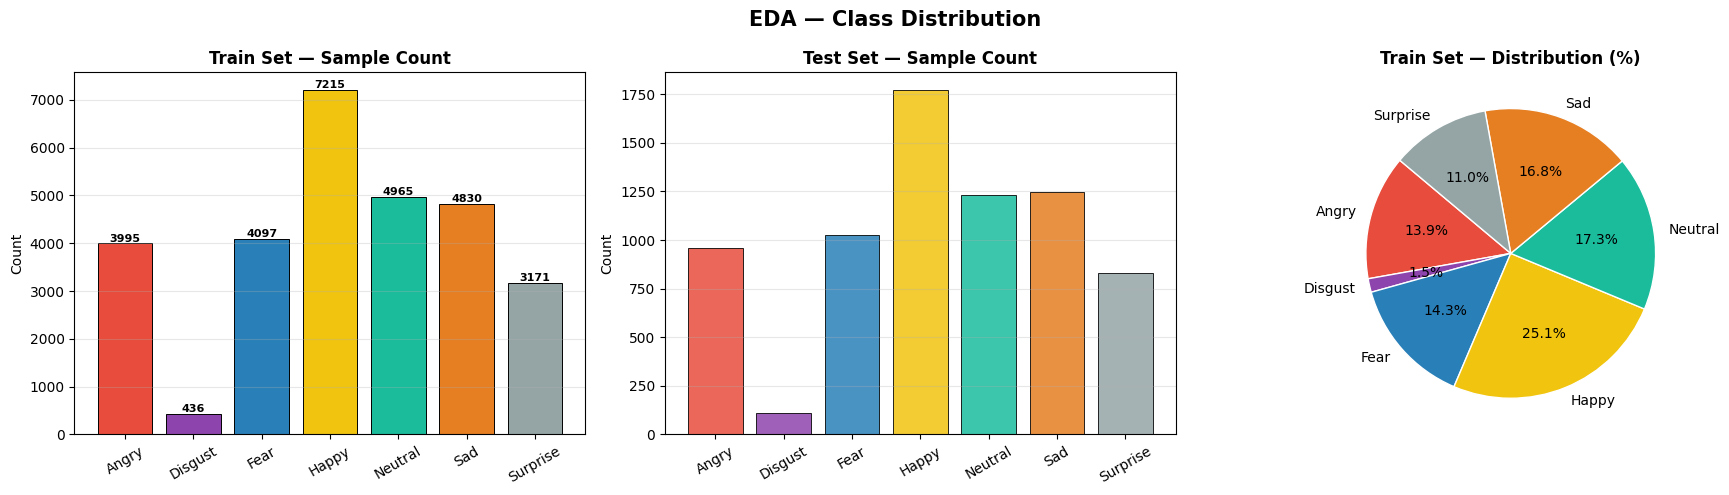


  Most common : happy (7215 images)
  Least common: disgust (436 images)
  Imbalance   : 16.5x


In [ ]:

# ============================================================
# CELL 4 — EDA: Class Distribution
# ============================================================
print("\n\n── EDA: Class Distribution ──")

train_counts = {e: len(list((TRAIN_DIR/e).glob("*"))) for e in EMOTIONS}
test_counts  = {e: len(list((TEST_DIR /e).glob("*"))) for e in EMOTIONS}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("EDA — Class Distribution", fontsize=15, fontweight='bold')

# Train bar chart
bars = axes[0].bar(EMOTION_DISPLAY,
                   [train_counts[e] for e in EMOTIONS],
                   color=COLORS, edgecolor='black', linewidth=0.7)
axes[0].set_title("Train Set — Sample Count", fontweight='bold')
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)
for bar, e in zip(bars, EMOTIONS):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 40, str(train_counts[e]),
                 ha='center', fontsize=8, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Test bar chart
axes[1].bar(EMOTION_DISPLAY,
            [test_counts[e] for e in EMOTIONS],
            color=COLORS, edgecolor='black', linewidth=0.7, alpha=0.85)
axes[1].set_title("Test Set — Sample Count", fontweight='bold')
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# Pie chart
axes[2].pie([train_counts[e] for e in EMOTIONS],
            labels=EMOTION_DISPLAY, autopct='%1.1f%%',
            colors=COLORS, startangle=140,
            wedgeprops=dict(edgecolor='white'))
axes[2].set_title("Train Set — Distribution (%)", fontweight='bold')

plt.tight_layout()
plt.savefig("eda_class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Most common : {max(train_counts, key=train_counts.get)} "
      f"({max(train_counts.values())} images)")
print(f"  Least common: {min(train_counts, key=train_counts.get)} "
      f"({min(train_counts.values())} images)")
print(f"  Imbalance   : {max(train_counts.values())/min(train_counts.values()):.1f}x")

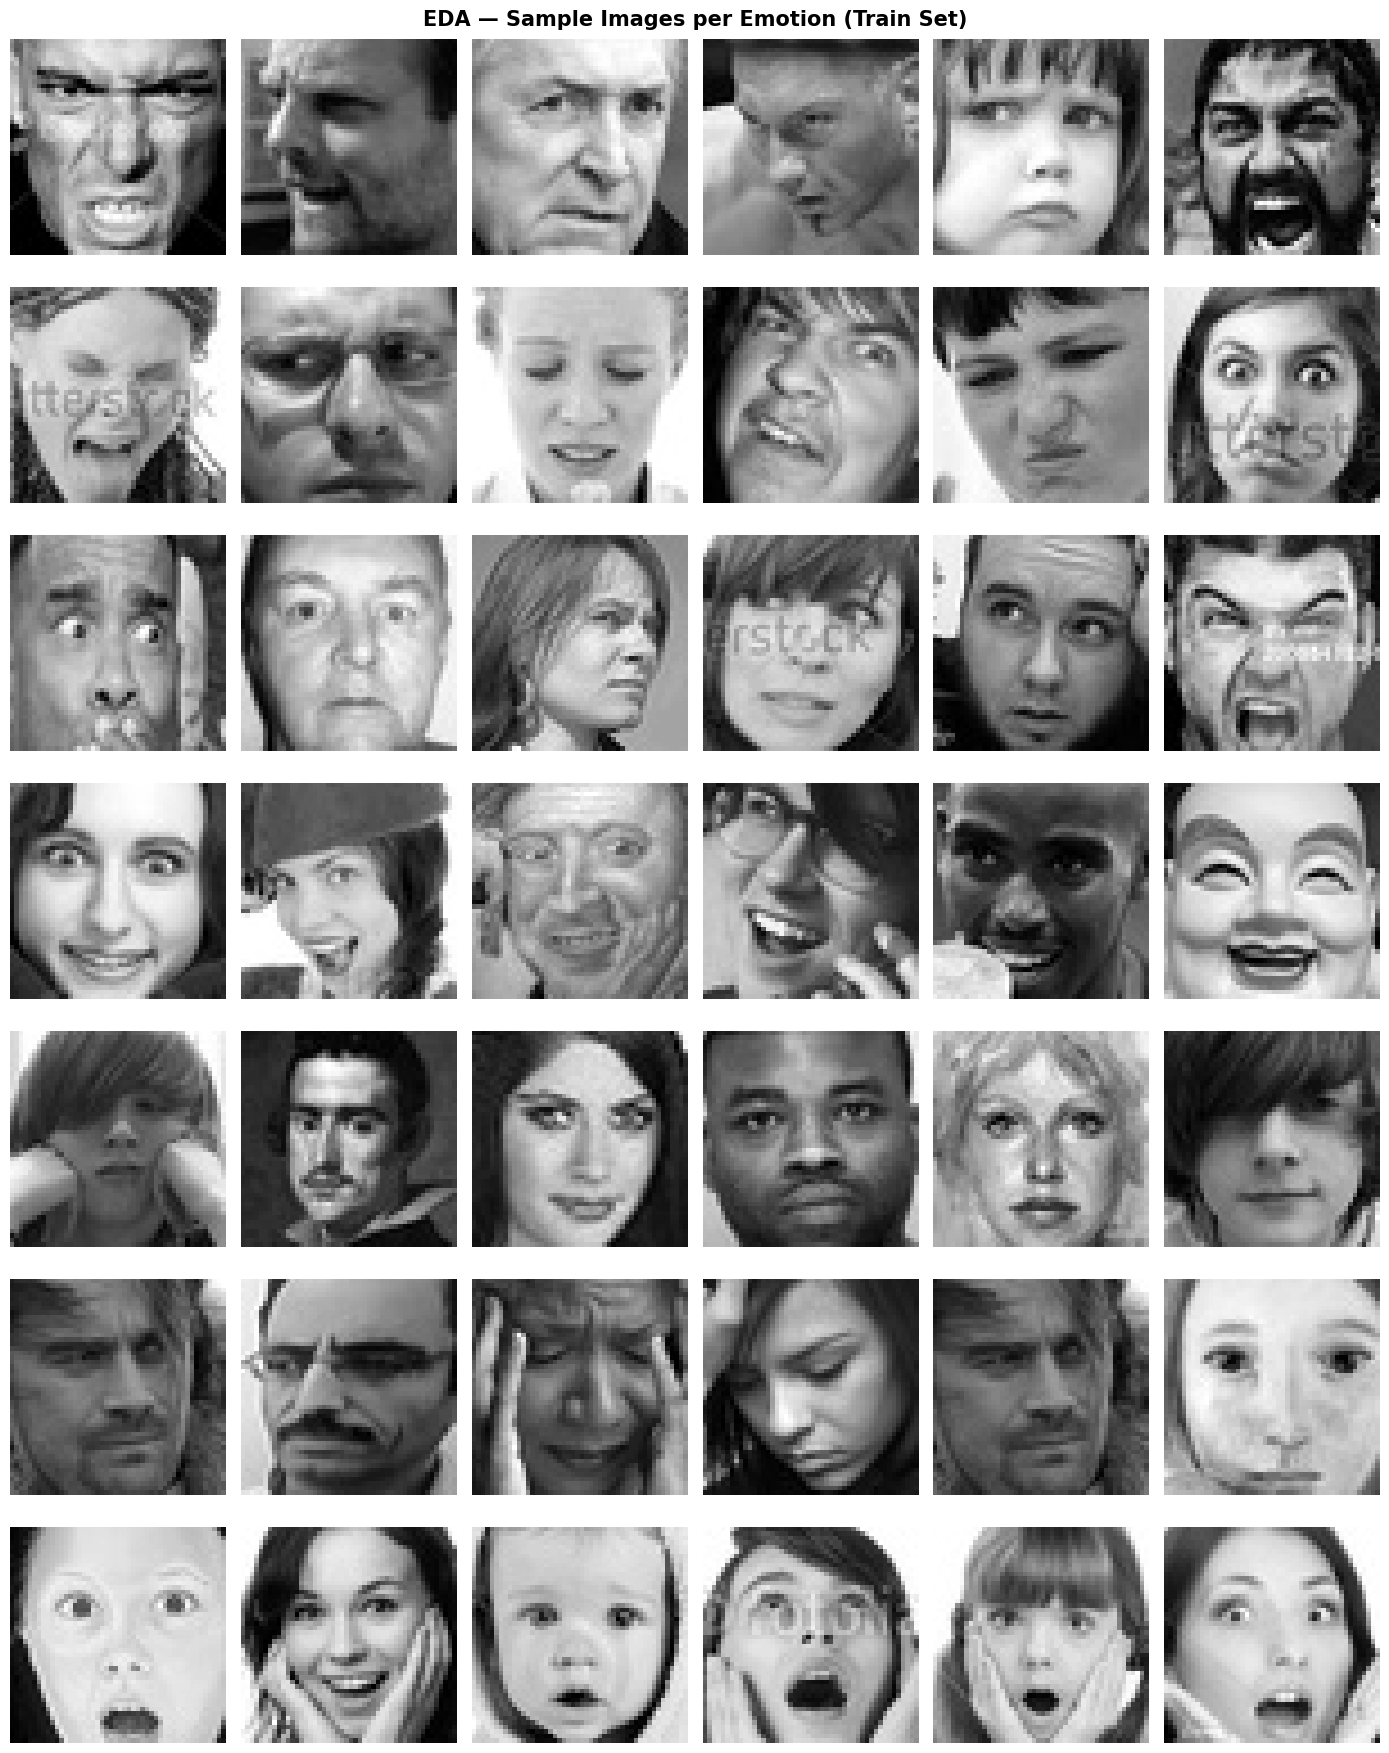

In [ ]:


# ============================================================
# CELL 5 — EDA: Sample Images per Emotion
# ============================================================
fig, axes = plt.subplots(7, 6, figsize=(14, 18))
fig.suptitle("EDA — Sample Images per Emotion (Train Set)",
             fontsize=15, fontweight='bold')

for i, emotion in enumerate(EMOTIONS):
    paths = (list((TRAIN_DIR/emotion).glob("*.png")) +
             list((TRAIN_DIR/emotion).glob("*.jpg")))[:6]
    for j, path in enumerate(paths):
        img = np.array(Image.open(path).convert('L'))
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].axis('off')
        if j == 0:
            axes[i][j].set_ylabel(EMOTION_DISPLAY[i], fontsize=11,
                                   fontweight='bold', rotation=0,
                                   labelpad=55, va='center')
plt.tight_layout()
plt.savefig("eda_sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

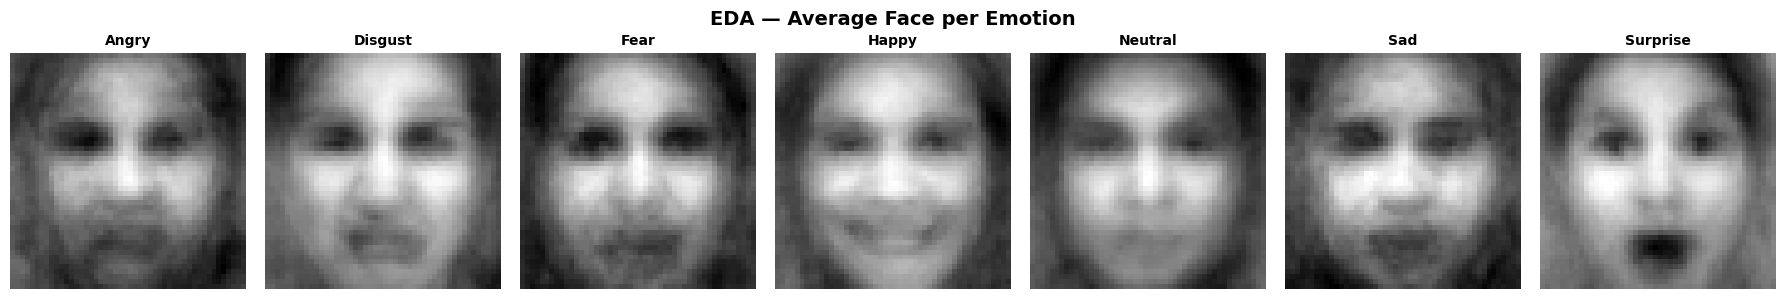

In [ ]:


# ============================================================
# CELL 6 — EDA: Average Face per Emotion
# ============================================================
fig, axes = plt.subplots(1, 7, figsize=(18, 3))
fig.suptitle("EDA — Average Face per Emotion", fontsize=14, fontweight='bold')

for i, emotion in enumerate(EMOTIONS):
    paths = (list((TRAIN_DIR/emotion).glob("*.png")) +
             list((TRAIN_DIR/emotion).glob("*.jpg")))[:200]
    imgs     = [np.array(Image.open(p).convert('L').resize((48, 48))) for p in paths]
    avg_face = np.mean(imgs, axis=0)
    axes[i].imshow(avg_face, cmap='gray')
    axes[i].set_title(EMOTION_DISPLAY[i], fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("eda_average_faces.png", dpi=150, bbox_inches='tight')
plt.show()

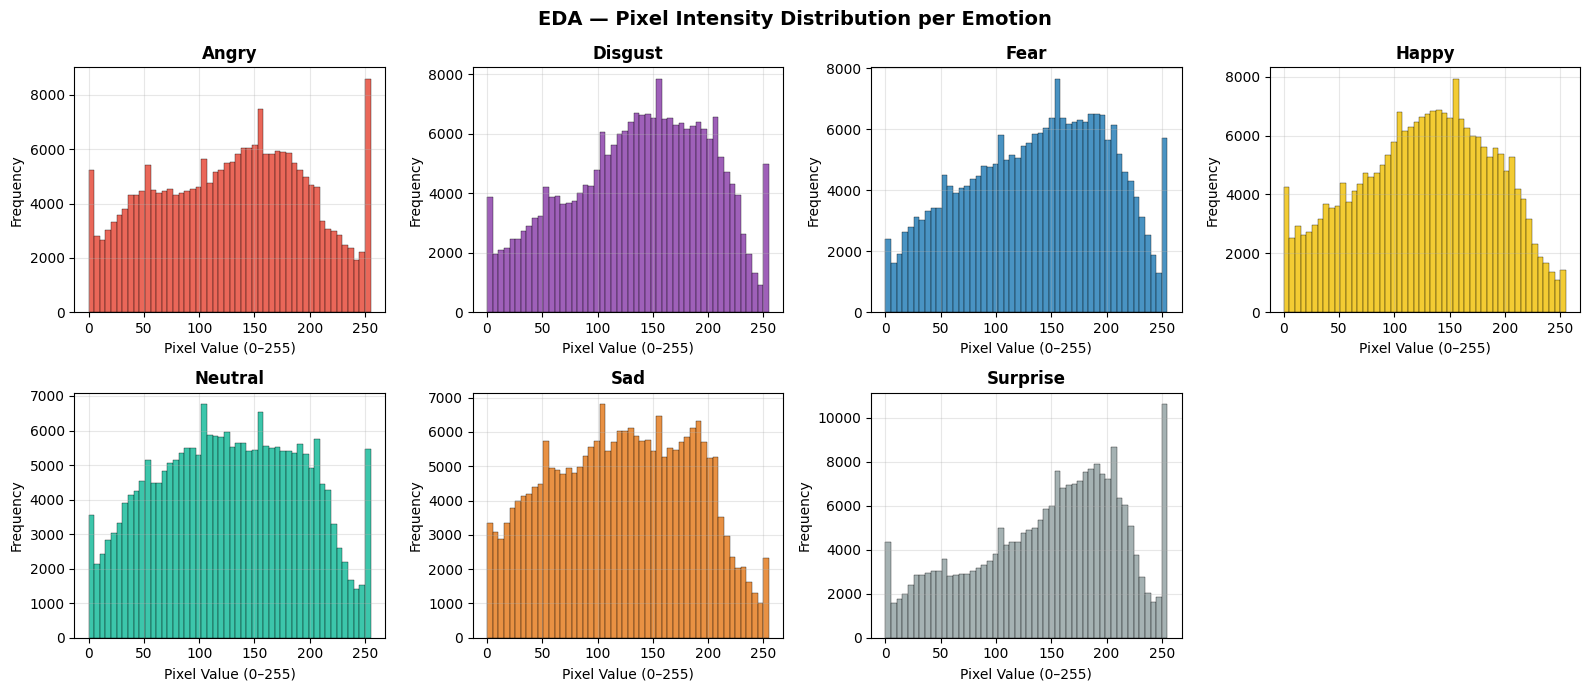

In [ ]:


# ============================================================
# CELL 7 — EDA: Pixel Intensity Distribution
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.suptitle("EDA — Pixel Intensity Distribution per Emotion",
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, emotion in enumerate(EMOTIONS):
    paths = (list((TRAIN_DIR/emotion).glob("*.png")) +
             list((TRAIN_DIR/emotion).glob("*.jpg")))[:100]
    pixels = []
    for p in paths:
        pixels.extend(np.array(Image.open(p).convert('L')).flatten().tolist())
    axes[i].hist(pixels, bins=50, color=COLORS[i],
                 edgecolor='black', linewidth=0.3, alpha=0.85)
    axes[i].set_title(EMOTION_DISPLAY[i], fontweight='bold')
    axes[i].set_xlabel("Pixel Value (0–255)")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(alpha=0.3)

axes[7].axis('off')
plt.tight_layout()
plt.savefig("eda_pixel_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:


# ============================================================
# CELL 8 — EDA: Image Quality Check
# ============================================================
print("\n── EDA: Image Quality Check ──")
sizes   = collections.Counter()
corrupt = 0

for emotion in EMOTIONS:
    for path in list((TRAIN_DIR/emotion).glob("*"))[:50]:
        try:
            sizes[Image.open(path).size] += 1
        except Exception:
            corrupt += 1

print(f"  Corrupted images : {corrupt}")
print(f"  Image sizes found:")
for size, count in sizes.most_common():
    print(f"    {size[0]}x{size[1]} px → {count} samples")



── EDA: Image Quality Check ──
  Corrupted images : 0
  Image sizes found:
    48x48 px → 350 samples


In [ ]:

# ============================================================
# CELL 9 — Data Generators
# ============================================================
print("\n\n── Setting up Data Generators ──")

# Augmented generator for training
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10,
    validation_split=0.15
).flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

# Clean generator for validation
val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
).flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

# Clean generator for test
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    color_mode='grayscale',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n✅ Class indices:", train_gen.class_indices)

# Compute class weights to handle Disgust imbalance
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print(f"\n✅ Class weights: {class_weights}")




── Setting up Data Generators ──
Found 24406 images belonging to 7 classes.
Found 4303 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.

✅ Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}

✅ Class weights: {0: np.float64(1.0266700319703854), 1: np.float64(9.397766653831344), 2: np.float64(1.0010253886222877), 3: np.float64(0.5684936293121521), 4: np.float64(0.8260060243002674), 5: np.float64(0.8491406304362953), 6: np.float64(1.2932386604493429)}


In [ ]:

# ============================================================
# CELL 10 — Shared Helpers
# ============================================================

def get_callbacks(model_name):
    """EarlyStopping + ReduceLR + save best checkpoint."""
    return [
        EarlyStopping(monitor='val_accuracy', patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
        ModelCheckpoint(f"best_{model_name}.keras",
                        monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

def plot_history(history, model_name):
    """Plot accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"Training History — {model_name}",
                 fontsize=13, fontweight='bold')

    axes[0].plot(history.history['accuracy'],
                 label='Train', color='steelblue', lw=2)
    axes[0].plot(history.history['val_accuracy'],
                 label='Val', color='tomato', lw=2)
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history['loss'],
                 label='Train', color='steelblue', lw=2)
    axes[1].plot(history.history['val_loss'],
                 label='Val', color='tomato', lw=2)
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"history_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

def evaluate_model(model, model_name, test_gen):
    """Evaluate model — print metrics, plot confusion matrix."""
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    test_gen.reset()
    y_pred = np.argmax(model.predict(test_gen, verbose=0), axis=1)
    y_true = test_gen.classes

    print(f"\n── {model_name} Results ──")
    print(f"  Test Loss    : {loss:.4f}")
    print(f"  Test Accuracy: {acc*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=EMOTION_DISPLAY))

    # Confusion matrix
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay(cm, display_labels=EMOTION_DISPLAY).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}", fontweight='bold')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f"cm_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

    return loss, acc, y_pred, y_true

results = {}   # {model_name: (loss, acc, y_pred, y_true)}

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]




══ MODEL 1: Custom CNN (loading saved checkpoint) ══
⚠️  No saved checkpoint found — training from scratch...
Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 53s 97ms/step - accuracy: 0.1819 - loss: 2.1871 - val_accuracy: 0.0193 - val_loss: 2.1836 - learning_rate: 0.0010
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 69ms/step - accuracy: 0.2085 - loss: 1.9251 - val_accuracy: 0.2375 - val_loss: 1.8702 - learning_rate: 0.0010
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.2423 - loss: 1.8405 - val_accuracy: 0.3040 - val_loss: 1.7374 - learning_rate: 0.0010
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.2966 - loss: 1.7299 - val_accuracy: 0.4306 - val_loss: 1.5194 - learning_rate: 0.0010
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.3488 - loss: 1.6511 - val_accuracy: 0.4044 - val_loss: 1.5381 - learning_rate: 0.0010
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.3883 - loss: 1.5648 - val_accuracy: 0.4367 - val_l

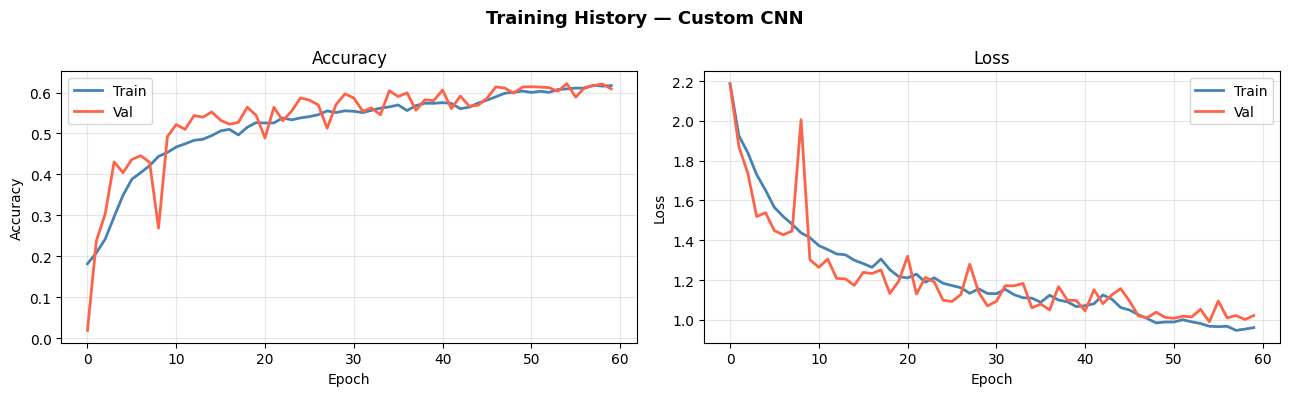


── Custom CNN Results ──
  Test Loss    : 0.9965
  Test Accuracy: 62.66%

  Classification Report:
              precision    recall  f1-score   support

       Angry       0.53      0.60      0.56       958
     Disgust       0.42      0.63      0.51       111
        Fear       0.49      0.36      0.42      1024
       Happy       0.89      0.82      0.85      1774
     Neutral       0.53      0.66      0.59      1233
         Sad       0.52      0.43      0.48      1247
    Surprise       0.71      0.81      0.76       831

    accuracy                           0.63      7178
   macro avg       0.58      0.62      0.59      7178
weighted avg       0.63      0.63      0.62      7178



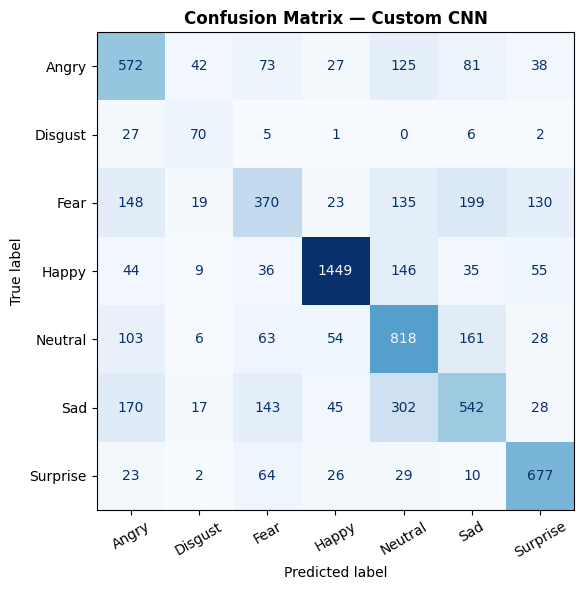

In [ ]:


# ============================================================
# CELL 11 — MODEL 1: Custom CNN (load saved checkpoint)
# ============================================================
print("\n\n══ MODEL 1: Custom CNN (loading saved checkpoint) ══")

# If you already trained CNN previously, just load it — no need to retrain!
import os

if os.path.exists("best_CNN.keras"):
    from tensorflow.keras.models import load_model
    cnn_model = load_model("best_CNN.keras")
    print("✅ Loaded saved CNN from best_CNN.keras")
else:
    print("⚠️  No saved checkpoint found — training from scratch...")

    cnn_model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(48, 48, 1)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2), Dropout(0.25),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2), Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2), Dropout(0.25),

        # Classifier head
        Flatten(),
        Dense(256, activation='relu'), BatchNormalization(), Dropout(0.5),
        Dense(128, activation='relu'), Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ], name="Custom_CNN")

    cnn_model.compile(optimizer=Adam(1e-3),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

    history_cnn = cnn_model.fit(
        train_gen, epochs=60, validation_data=val_gen,
        class_weight=class_weights,
        callbacks=get_callbacks("CNN"), verbose=1
    )
    plot_history(history_cnn, "Custom CNN")

results["Custom CNN"] = evaluate_model(cnn_model, "Custom CNN", test_gen)



══ MODEL 2: Deep Residual CNN ══


Model: "Deep_Residual_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 48, 48,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 48, 48,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 48, 48,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 48, 48,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 24, 24,    │     18,496 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 24, 24,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 24, 24,    │      2,112 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 24,    │          0 │ add_1[0][0]     

 Total params: 1,701,319 (6.49 MB)

 Trainable params: 1,697,159 (6.47 MB)

 Non-trainable params: 4,160 (16.25 KB)

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 65s 108ms/step - accuracy: 0.1553 - loss: 2.1464 - val_accuracy: 0.1736 - val_loss: 1.9381 - learning_rate: 0.0010
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.1677 - loss: 1.9617 - val_accuracy: 0.1002 - val_loss: 1.9518 - learning_rate: 0.0010
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.1795 - loss: 1.9109 - val_accuracy: 0.0709 - val_loss: 1.9727 - learning_rate: 0.0010
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.2047 - loss: 1.8383 - val_accuracy: 0.1848 - val_loss: 1.8717 - learning_rate: 0.0010
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.2153 - loss: 1.7879 - val_accuracy: 0.2261 - val_loss: 1.7626 - learning_rate: 0.0010
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 68ms/step - accuracy: 0.2550 - loss: 1.7516 - val_accuracy: 0.2696 - val_loss: 1.7632 - learning_rate: 0.0010
Epoch 7/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 26s 67ms/step - accuracy: 0.3074 - 

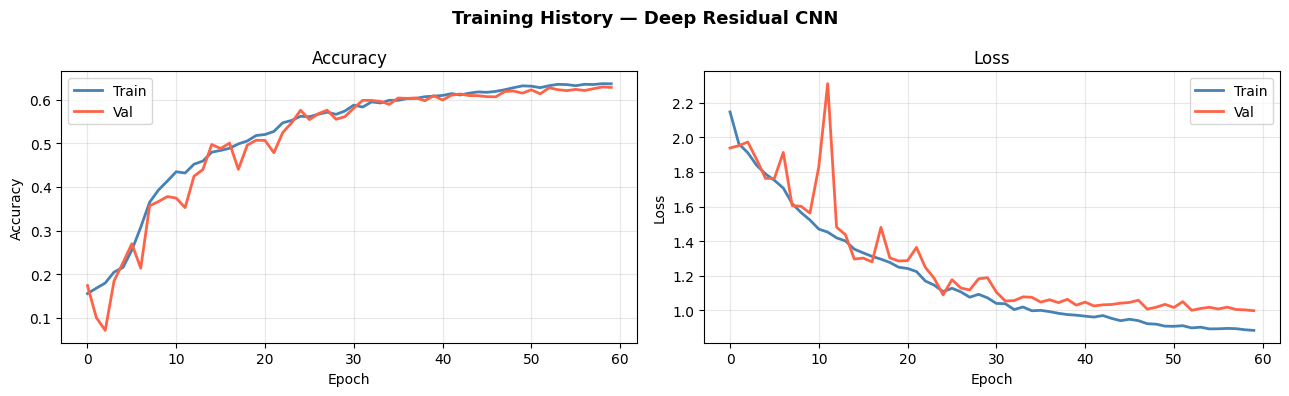


── Deep Residual CNN Results ──
  Test Loss    : 1.0058
  Test Accuracy: 63.04%

  Classification Report:
              precision    recall  f1-score   support

       Angry       0.55      0.57      0.56       958
     Disgust       0.36      0.73      0.48       111
        Fear       0.52      0.28      0.36      1024
       Happy       0.88      0.82      0.85      1774
     Neutral       0.54      0.70      0.61      1233
         Sad       0.50      0.47      0.48      1247
    Surprise       0.71      0.84      0.77       831

    accuracy                           0.63      7178
   macro avg       0.58      0.63      0.59      7178
weighted avg       0.63      0.63      0.62      7178



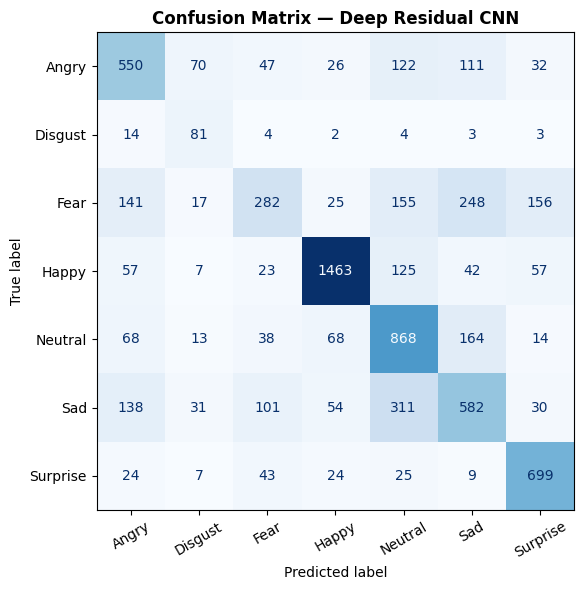

In [ ]:


# ============================================================
# CELL 12 — MODEL 2: Deep Residual CNN
# ============================================================
# What makes this different from Model 1:
#   - Residual (skip) connections: output = F(x) + x
#   - Prevents vanishing gradients in deeper networks
#   - Learns both fine and coarse features simultaneously
#   - More parameters, more representational power
# ============================================================
print("\n\n══ MODEL 2: Deep Residual CNN ══")

def residual_block(x, filters, downsample=False):
    """
    A residual block: two Conv layers with a skip connection.
    If downsample=True, reduces spatial size by 2 using stride.
    """
    stride = 2 if downsample else 1

    # Main path
    out = Conv2D(filters, (3,3), strides=stride,
                 padding='same', activation='relu')(x)
    out = BatchNormalization()(out)
    out = Conv2D(filters, (3,3), padding='same')(out)
    out = BatchNormalization()(out)

    # Skip connection — match dimensions if needed
    if downsample or x.shape[-1] != filters:
        x = Conv2D(filters, (1,1), strides=stride, padding='same')(x)
        x = BatchNormalization()(x)

    # Add skip + main, then activate
    out = Add()([out, x])
    out = Activation('relu')(out)
    return out

def build_residual_cnn():
    inputs = Input(shape=(48, 48, 1))

    # Entry block
    x = Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)

    # Residual blocks — gradually increase filters
    x = residual_block(x, 32)
    x = residual_block(x, 64,  downsample=True)   # 24x24
    x = Dropout(0.25)(x)

    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)   # 12x12
    x = Dropout(0.25)(x)

    x = residual_block(x, 128)
    x = residual_block(x, 256, downsample=True)   # 6x6
    x = Dropout(0.25)(x)

    # Global pooling instead of Flatten — more robust
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)

    model = Model(inputs, outputs, name="Deep_Residual_CNN")
    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

res_cnn = build_residual_cnn()
res_cnn.summary()

history_res = res_cnn.fit(
    train_gen, epochs=60, validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks("ResCNN"), verbose=1
)

plot_history(history_res, "Deep Residual CNN")
results["Deep Residual CNN"] = evaluate_model(res_cnn, "Deep Residual CNN", test_gen)



══ MODEL 3: Mini VGG CNN ══


Model: "Mini_VGG_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 128)    │       147,58

 Total params: 2,718,535 (10.37 MB)

 Trainable params: 2,714,631 (10.36 MB)

 Non-trainable params: 3,904 (15.25 KB)

Epoch 1/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 58s 100ms/step - accuracy: 0.1527 - loss: 2.3093 - val_accuracy: 0.1920 - val_loss: 1.9344 - learning_rate: 0.0010
Epoch 2/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.1618 - loss: 2.0193 - val_accuracy: 0.2412 - val_loss: 1.8470 - learning_rate: 0.0010
Epoch 3/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.1853 - loss: 1.9219 - val_accuracy: 0.1857 - val_loss: 1.9060 - learning_rate: 0.0010
Epoch 4/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.2215 - loss: 1.8475 - val_accuracy: 0.1622 - val_loss: 1.9702 - learning_rate: 0.0010
Epoch 5/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.2624 - loss: 1.7818 - val_accuracy: 0.2254 - val_loss: 1.8616 - learning_rate: 0.0010
Epoch 6/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.3143 - loss: 1.7048 - val_accuracy: 0.2740 - val_loss: 1.8003 - learning_rate: 0.0010
Epoch 7/60
382/382 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.3429 - 

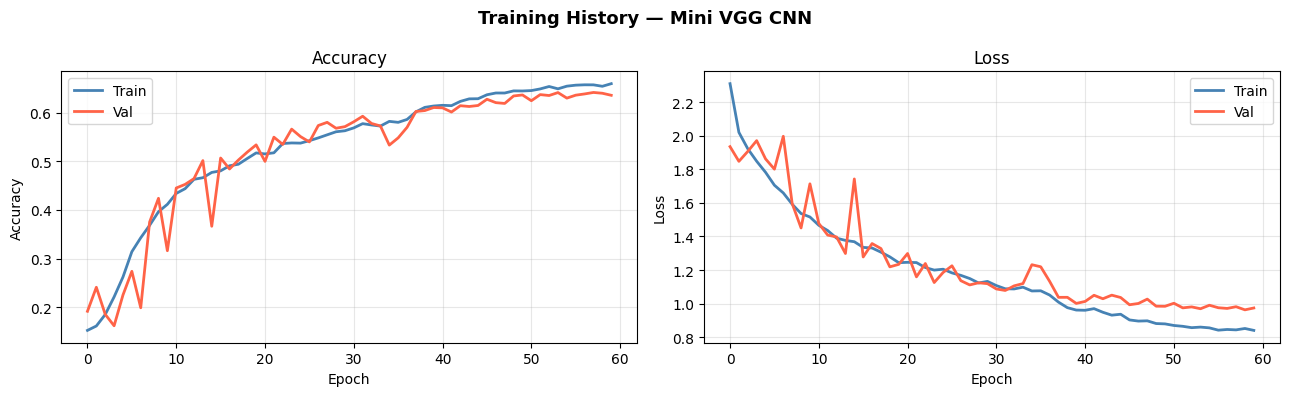


── Mini VGG CNN Results ──
  Test Loss    : 0.9779
  Test Accuracy: 63.92%

  Classification Report:
              precision    recall  f1-score   support

       Angry       0.57      0.58      0.57       958
     Disgust       0.41      0.72      0.52       111
        Fear       0.53      0.34      0.42      1024
       Happy       0.90      0.81      0.85      1774
     Neutral       0.52      0.76      0.62      1233
         Sad       0.55      0.44      0.49      1247
    Surprise       0.71      0.83      0.77       831

    accuracy                           0.64      7178
   macro avg       0.60      0.64      0.60      7178
weighted avg       0.65      0.64      0.63      7178



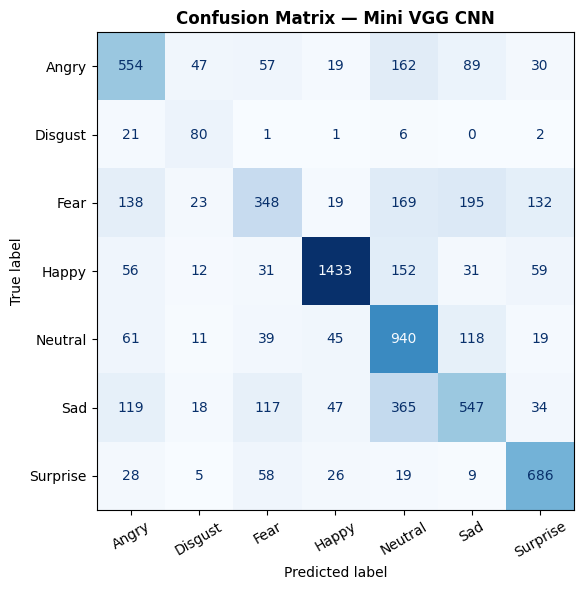

In [ ]:


# ============================================================
# CELL 13 — MODEL 3: Mini VGG CNN
# ============================================================
# What makes this different:
#   - VGG-style: many small 3x3 conv layers stacked deeply
#   - No skip connections — pure sequential depth
#   - Proven architecture for face-related tasks
#   - Uses more conv layers per block than Model 1
#   - Different head: larger dense layers
# ============================================================
print("\n\n══ MODEL 3: Mini VGG CNN ══")

def build_mini_vgg():
    model = Sequential([
        # Block 1 — 3 conv layers
        Conv2D(32, (3,3), padding='same', activation='relu',
               input_shape=(48, 48, 1)),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),           # → 24x24
        Dropout(0.25),

        # Block 2 — 3 conv layers
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),           # → 12x12
        Dropout(0.25),

        # Block 3 — 3 conv layers
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),           # → 6x6
        Dropout(0.25),

        # Block 4 — 2 conv layers (deeper than Model 1)
        Conv2D(256, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(256, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2, 2),           # → 3x3
        Dropout(0.25),

        # Classifier head — larger than Model 1
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ], name="Mini_VGG_CNN")

    model.compile(optimizer=Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

vgg_model = build_mini_vgg()
vgg_model.summary()

history_vgg = vgg_model.fit(
    train_gen, epochs=60, validation_data=val_gen,
    class_weight=class_weights,
    callbacks=get_callbacks("MiniVGG"), verbose=1
)

plot_history(history_vgg, "Mini VGG CNN")
results["Mini VGG CNN"] = evaluate_model(vgg_model, "Mini VGG CNN", test_gen)



══ MODEL COMPARISON ══


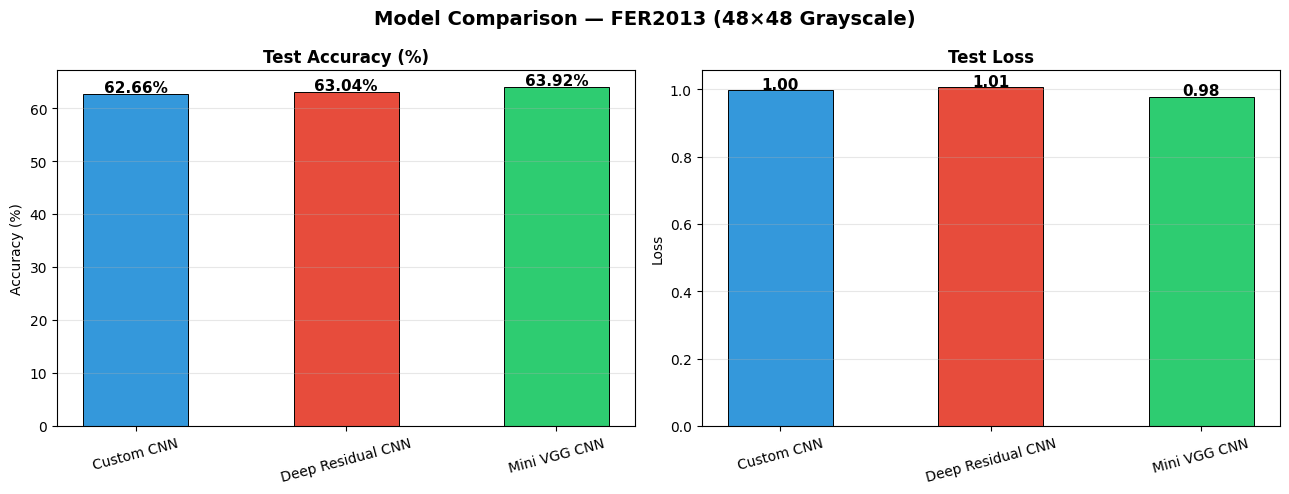

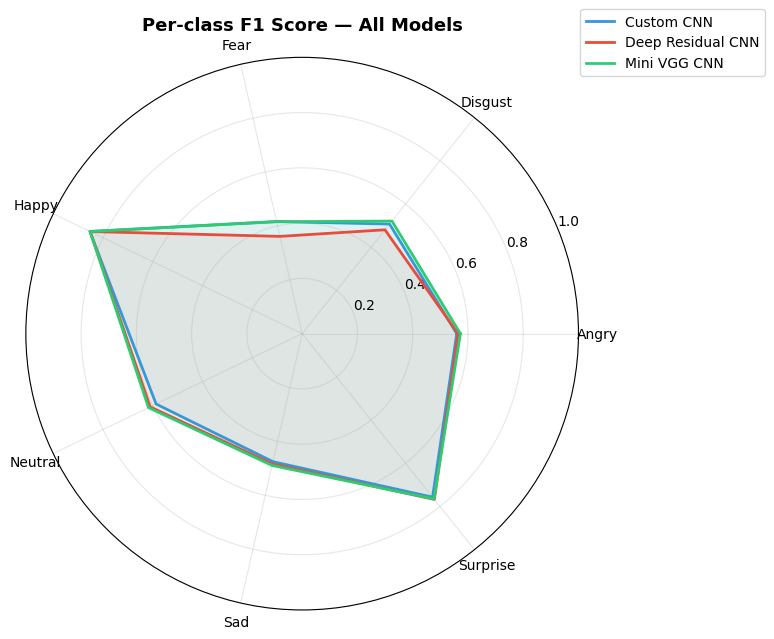

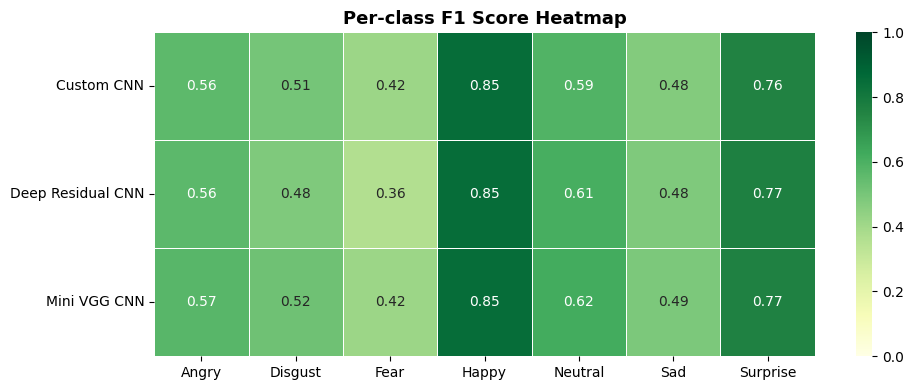


  ┌────────────────────┬──────────────┬───────────┐
  │ Model              │ Test Acc (%) │ Test Loss │
  ├────────────────────┼──────────────┼───────────┤
  │ Custom CNN         │    62.66%    │  0.9965  │
  │ Deep Residual CNN  │    63.04%    │  1.0058  │
  │ Mini VGG CNN       │    63.92%    │  0.9779  │ ✅
  └────────────────────┴──────────────┴───────────┘

  🏆 Best Model : Mini VGG CNN
  🎯 Accuracy   : 63.92%

  📌 Note: Human-level accuracy on FER2013 is ~65%
           Anything above 60% is considered strong performance.


In [ ]:


# ============================================================
# CELL 14 — Model Comparison
# ============================================================
print("\n\n══ MODEL COMPARISON ══")

model_names = list(results.keys())
accuracies  = [results[m][1] * 100 for m in model_names]
losses      = [results[m][0]       for m in model_names]
bar_colors  = ['#3498db', '#e74c3c', '#2ecc71']

# ── Accuracy & Loss bar charts ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Comparison — FER2013 (48×48 Grayscale)",
             fontsize=14, fontweight='bold')

for ax, values, title, ylabel in [
    (axes[0], accuracies, "Test Accuracy (%)", "Accuracy (%)"),
    (axes[1], losses,     "Test Loss",          "Loss")
]:
    bars = ax.bar(model_names, values, color=bar_colors,
                  edgecolor='black', linewidth=0.7, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.4 if "%" in ylabel else 0.005),
                f"{val:.2f}" + ("%" if "%" in ylabel else ""),
                ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Per-class F1 Radar Chart ─────────────────────────────────
f1_scores = {name: f1_score(results[name][3], results[name][2], average=None)
             for name in model_names}

N      = NUM_CLASSES
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0.0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_title("Per-class F1 Score — All Models",
             fontsize=13, fontweight='bold', pad=20)

for (name, f1), color in zip(f1_scores.items(), bar_colors):
    vals = list(f1) + [f1[0]]
    ax.plot(angles, vals, linewidth=2, label=name, color=color)
    ax.fill(angles, vals, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(EMOTION_DISPLAY, fontsize=10)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("radar_f1.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Per-emotion accuracy heatmap ─────────────────────────────
f1_matrix = np.array([f1_scores[name] for name in model_names])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(f1_matrix,
            annot=True, fmt=".2f",
            xticklabels=EMOTION_DISPLAY,
            yticklabels=model_names,
            cmap="YlGn", vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Per-class F1 Score Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("f1_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Table ────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k][1])

print("\n  ┌────────────────────┬──────────────┬───────────┐")
print("  │ Model              │ Test Acc (%) │ Test Loss │")
print("  ├────────────────────┼──────────────┼───────────┤")
for name in model_names:
    loss, acc = results[name][0], results[name][1]
    tag = " ✅" if name == best_name else ""
    print(f"  │ {name:<18} │   {acc*100:6.2f}%    │  {loss:.4f}  │{tag}")
print("  └────────────────────┴──────────────┴───────────┘")
print(f"\n  🏆 Best Model : {best_name}")
print(f"  🎯 Accuracy   : {results[best_name][1]*100:.2f}%")
print(f"\n  📌 Note: Human-level accuracy on FER2013 is ~65%")
print(f"           Anything above 60% is considered strong performance.")


In [ ]:

# ============================================================
# CELL 15 — Save Best Model
# ============================================================
model_objects = {
    "Custom CNN"       : cnn_model,
    "Deep Residual CNN": res_cnn,
    "Mini VGG CNN"     : vgg_model,
}

best_model = model_objects[best_name]
best_model.save("best_emotion_model.keras")
best_model.save("best_emotion_model.h5")

print("\n✅ Saved: best_emotion_model.keras")
print("✅ Saved: best_emotion_model.h5")
print("\n📥 To download from Colab run:")
print("   from google.colab import files")
print("   files.download('best_emotion_model.keras')")




✅ Saved: best_emotion_model.keras
✅ Saved: best_emotion_model.h5

📥 To download from Colab run:
   from google.colab import files
   files.download('best_emotion_model.keras')


In [ ]:
from google.colab import files
files.download('best_emotion_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>